# BAB 12 — CROSS-VALIDATION AND MODEL EVALUATION

## 12.1 Pengenalan

Sebelumnya kita sering membagi dataset menjadi:

Training data
→ digunakan untuk belajar.

Testing data
→ digunakan untuk menguji model.

Namun satu kali pembagian data dapat memberikan hasil yang kurang stabil.

Cross-validation digunakan untuk mengevaluasi model menggunakan beberapa pembagian data.

Salah satu metode paling umum adalah K-Fold Cross-Validation.

## 12.2 K-Fold Cross-Validation

Pada K-Fold, dataset dibagi menjadi K bagian.

Contoh K = 5:

Fold 1 → testing
Fold 2,3,4,5 → training

Kemudian bergantian sampai semua fold pernah menjadi data testing.

Hasil akhirnya biasanya berupa rata-rata skor dari seluruh fold.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold

data = load_iris()

X = data.data
y = data.target

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_index, test_index in kf.split(X):
    print(
        "Train:",
        len(train_index),
        "Test:",
        len(test_index)
    )

Train: 120 Test: 30
Train: 120 Test: 30
Train: 120 Test: 30
Train: 120 Test: 30
Train: 120 Test: 30


## 12.3 Stratified K-Fold

Untuk classification, StratifiedKFold sering digunakan.

Perbedaannya:

KFold hanya membagi data.

StratifiedKFold berusaha mempertahankan proporsi setiap kelas pada setiap fold.

Ini berguna terutama ketika jumlah data antar kelas tidak seimbang.

In [2]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_index, test_index in skf.split(X, y):
    print(
        "Train:",
        len(train_index),
        "Test:",
        len(test_index)
    )

Train: 120 Test: 30
Train: 120 Test: 30
Train: 120 Test: 30
Train: 120 Test: 30
Train: 120 Test: 30


## 12.4 cross_val_score

scikit-learn menyediakan cross_val_score untuk melakukan cross-validation dengan lebih mudah.

In [3]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Score setiap fold:", scores)
print("Rata-rata:", scores.mean())

Score setiap fold: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Rata-rata: 0.9733333333333334


## 12.5 Grid Search

Grid Search digunakan untuk mencari kombinasi hyperparameter terbaik dari beberapa pilihan yang sudah kita tentukan.

Contoh:

C = 0.1, 1, 10

Model akan mencoba semua kombinasi tersebut menggunakan cross-validation.

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X, y)

print("Parameter terbaik:", grid.best_params_)
print("Score terbaik:", grid.best_score_)

Parameter terbaik: {'C': 100}
Score terbaik: 0.9800000000000001


## 12.6 Randomized Search

Grid Search mencoba semua kombinasi.

Randomized Search hanya mencoba sejumlah kombinasi secara acak.

Randomized Search dapat lebih cepat ketika jumlah hyperparameter sangat banyak.

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

random_search = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=5,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search.fit(X, y)

print("Parameter terbaik:", random_search.best_params_)
print("Score terbaik:", random_search.best_score_)

Parameter terbaik: {'solver': 'liblinear', 'C': 100}
Score terbaik: 0.9800000000000001


## 12.7 Learning Curve

Learning curve digunakan untuk melihat hubungan antara jumlah data training dengan performa model.

Learning curve dapat membantu mengetahui apakah model mengalami:

- underfitting
- overfitting
- kekurangan data training

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
    

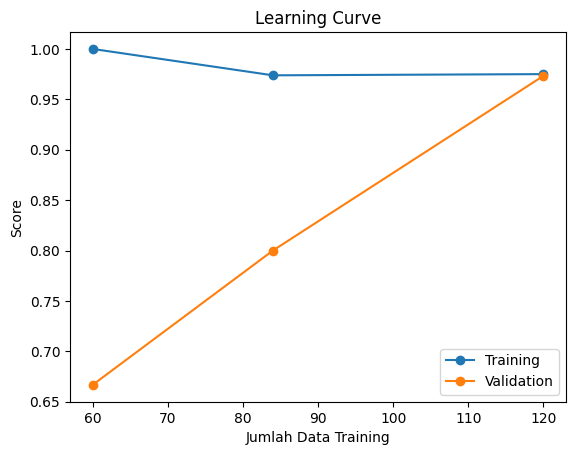

In [6]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

model = LogisticRegression(
    max_iter=1000
)

train_sizes, train_scores, validation_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0]
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation"
)

plt.xlabel("Jumlah Data Training")
plt.ylabel("Score")
plt.legend()
plt.title("Learning Curve")
plt.show()

## 12.8 Model Evaluation

Beberapa metric yang umum digunakan:

Classification:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Regression:
- MAE
- MSE
- RMSE
- R²

Metric harus dipilih sesuai dengan jenis masalah dan tujuan model.

## 12.9 Kesimpulan Bab 12

Pada bab ini kita mempelajari:

- Cross-validation.
- K-Fold.
- Stratified K-Fold.
- cross_val_score.
- GridSearchCV.
- RandomizedSearchCV.
- Learning Curve.
- Model evaluation.

Cross-validation membantu kita mendapatkan gambaran performa model yang lebih stabil daripada hanya menggunakan satu kali train-test split.